Dataset Preview
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60       RL          NaN    10382   Pave   NaN      IR1   
8   9          50       RM         51.0     6120   Pave   NaN      Reg   
9  10         190       RL         50.0     7420   Pave   NaN      Reg   

  LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
0         Lvl    AllPub  ...        0    NaN    NaN         NaN       0   
1         Lvl    Al

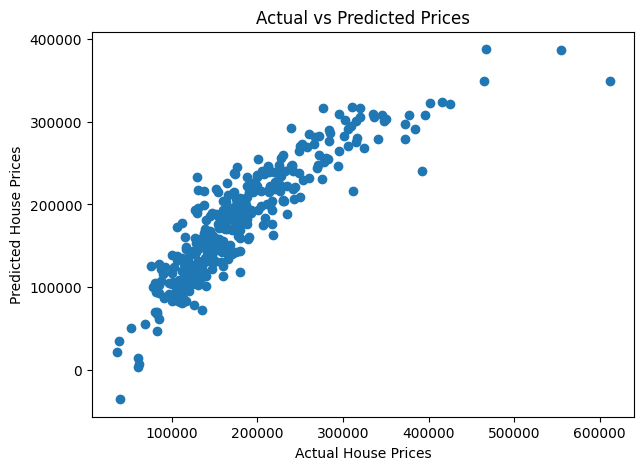


Feature Importance
       Features        Values
0   OverallQual  20864.652223
1     GrLivArea     58.431579
2    GarageCars  13941.073327
3   TotalBsmtSF     17.285400
4     YearBuilt    334.822014
5      FullBath  -1952.473635
6  BedroomAbvGr  -7238.635695
7       LotArea      0.627500


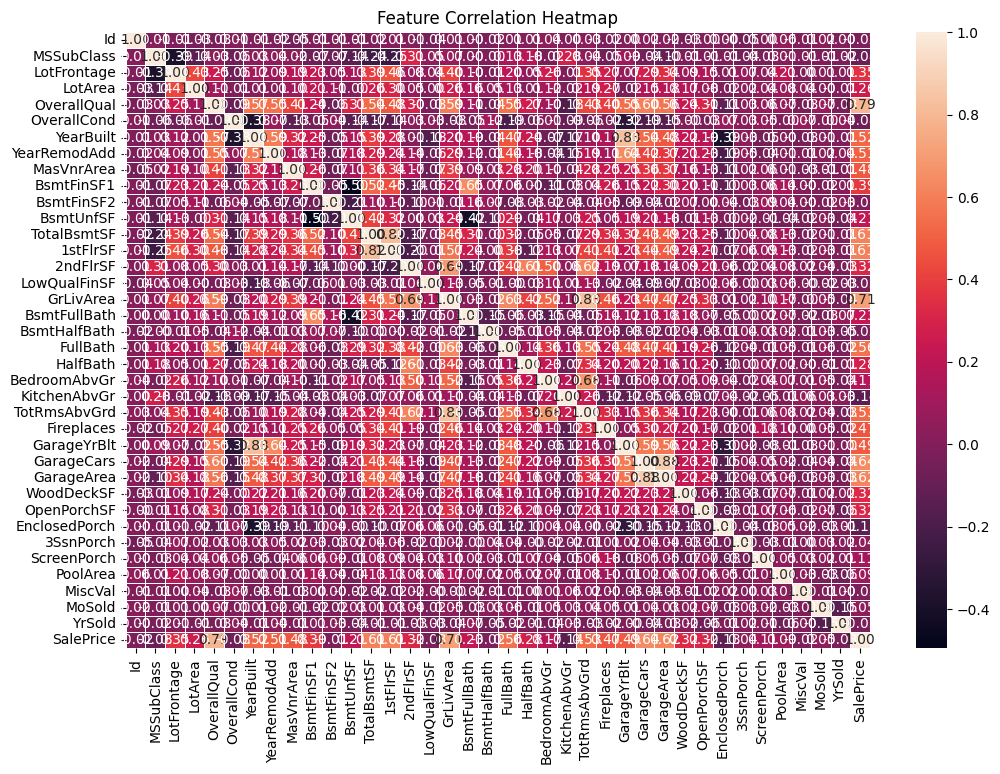

In [ ]:
# =========================================
# House Price Prediction using ML
# Algorithm : Linear Regression
# =========================================

# STEP 1 — Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# STEP 2 — Read Dataset

data = pd.read_csv("/content/train.csv")

print("Dataset Preview")
print(data.head(10))

print("\nShape of Dataset")
print(data.shape)

print("\nNull Values")
print(data.isnull().sum())

# STEP 3 — Define Input and Output

features = data[['OverallQual',
                 'GrLivArea',
                 'GarageCars',
                 'TotalBsmtSF',
                 'YearBuilt',
                 'FullBath',
                 'BedroomAbvGr',
                 'LotArea']]

target = data['SalePrice']

# STEP 4 — Split Dataset

x_train, x_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.25,
    random_state=10
)

print("\nTraining Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)

# STEP 5 — Create and Train Model

lr_model = LinearRegression()

lr_model.fit(x_train, y_train)

print("\nModel Successfully Trained")

# STEP 6 — Predict House Prices

predictions = lr_model.predict(x_test)

print("\nSample Predictions")
print(predictions[:10])

# STEP 7 — Evaluate Model

MAE = mean_absolute_error(y_test, predictions)

MSE = mean_squared_error(y_test, predictions)

RMSE = np.sqrt(MSE)

R2 = r2_score(y_test, predictions)

print("\nEvaluation Metrics")
print("Mean Absolute Error :", MAE)
print("Mean Squared Error  :", MSE)
print("Root Mean Squared Error :", RMSE)
print("R2 Score :", R2)

# STEP 8 — Actual vs Predicted Table

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

print("\nActual vs Predicted Prices")
print(comparison.head(10))

# STEP 9 — Visualization

plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

# STEP 10 — Feature Coefficients

importance = pd.DataFrame({
    "Features": features.columns,
    "Values": lr_model.coef_
})

print("\nFeature Importance")
print(importance)

# STEP 11 — Correlation Heatmap

plt.figure(figsize=(12,8))

numeric_data = data.select_dtypes(include='number')

sns.heatmap(numeric_data.corr(),
            annot=True,
            linewidths=0.5,
            fmt='.2f')

plt.title("Feature Correlation Heatmap")

plt.show()